# Evolutionary Aircraft Design Optimisation

## 1. Imports and constaints

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

rho = 1.225    # air density [kg/m^3]
V   = 230.0    # cruise speed [m/s]
e   = 0.8      # Oswald efficiency factor
W   = 7.0e5    # aircraft weight [N]
k_f = 0.45     # fuel-volume efficiency coefficient
k_c = 0.60     # cargo-volume efficiency coefficient

V_fuel_min  = 80.0     # minimum fuel volume [m^3]
V_cargo_min = 120.0    # minimum cargo volume [m^3]
AR_min,  AR_max  = 6.0,  14.0
S_w_min, S_w_max = 80.0, 300.0

## 2. Design variables

Each candidate aircraft is a real-valued vector of 6 variables:

| Variable | Description | Range |
|----------|-------------|-------|
| b | Wing span [m] | 20 – 80 |
| S_w | Wing area [m²] | 80 – 300 |
| Λ | Sweep angle [°] | 0 – 45 |
| t_c | Thickness-to-chord ratio | 0.08 – 0.20 |
| L_f | Fuselage length [m] | 20 – 60 |
| D_f | Fuselage diameter [m] | 3 – 7 |

AR = b^2 / S_w

In [2]:
BOUNDS = [
    (20.0, 80.0),    # b   – wing span [m]
    (80.0, 300.0),   # S_w – wing area [m^2]
    (0.0,  45.0),    # Λ   – sweep angle [degrees]
    (0.08, 0.20),    # t_c – thickness-to-chord ratio
    (20.0, 60.0),    # L_f – fuselage length [m]
    (3.0,  7.0),     # D_f – fuselage diameter [m]
]
N_VARS = len(BOUNDS)

## 3. Objective and constraint functions

In [3]:
def evaluate_aircraft(x):
    """Return (C_D, V_fuel, V_cargo, AR) for design vector x."""
    b, S_w, sweep, t_c, L_f, D_f = x

    AR    = b**2 / S_w
    C_L   = 2 * W / (rho * V**2 * S_w)
    C_D0  = 0.018 + 0.002 * (D_f / L_f) + 0.0001 * abs(sweep)  # zero-lift drag
    C_Di  = C_L**2 / (np.pi * e * AR)                            # induced drag
    C_D   = C_D0 + C_Di

    V_fuel  = k_f * S_w * (S_w / b) * t_c   # fuel stored in wings
    V_cargo = k_c * L_f * D_f**2             # cargo in fuselage

    return C_D, V_fuel, V_cargo, AR


def constraint_violation(x):
    """
    Sum of squared constraint violations.
    Returns 0.0 for a feasible design, > 0 otherwise.
    """
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    _, S_w, *_ = x

    violations = [
        max(0.0, V_fuel_min  - V_fuel),   # fuel volume too low
        max(0.0, V_cargo_min - V_cargo),  # cargo volume too low
        max(0.0, AR_min - AR),            # AR below minimum
        max(0.0, AR - AR_max),            # AR above maximum
        max(0.0, S_w_min - S_w),          # wing area too small
        max(0.0, S_w - S_w_max),          # wing area too large
    ]
    return sum(v**2 for v in violations)


def objectives(x):
    """Raw objective vector [C_D, -V_fuel, -V_cargo] - all minimised."""
    C_D, V_fuel, V_cargo, _ = evaluate_aircraft(x)
    return np.array([C_D, -V_fuel, -V_cargo])


# Penalty weight: must be large enough that any infeasible design
# scores worse than any feasible one on every objective.
PENALTY_WEIGHT = 1e4

def penalised_objectives(x):
    """Objectives with constraint penalty added - used during evolution."""
    return objectives(x) + PENALTY_WEIGHT * constraint_violation(x)

x_example = np.array([42.0, 140.0, 25.0, 0.12, 38.0, 4.5])
C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x_example)
print(f"Example design → C_D={C_D:.5f}, V_fuel={V_fuel:.1f} m^3, "
      f"V_cargo={V_cargo:.1f} m^3, AR={AR:.2f}")
print(f"Constraint violation: {constraint_violation(x_example):.4f}")

Example design → C_D=0.02149, V_fuel=25.2 m^3, V_cargo=461.7 m^3, AR=12.60
Constraint violation: 3003.0400


## 4. NSGA-II - core operations

In [4]:
def dominates(a, b):
    """True if objective vector a dominates b (no worse in all, better in at least one)."""
    return np.all(a <= b) and np.any(a < b)


def non_dominated_sort(pop_obj):
    """
    Assign each individual to a Pareto rank (0 = best front).
    Returns a list of fronts, where fronts[0] is the Pareto front.
    """
    n = len(pop_obj)
    dom_count = np.zeros(n, dtype=int)  # how many solutions dominate individual i
    dom_by    = [[] for _ in range(n)] # list of solutions that i dominates

    for i in range(n):
        for j in range(i + 1, n):
            if dominates(pop_obj[i], pop_obj[j]):
                dom_by[i].append(j)
                dom_count[j] += 1
            elif dominates(pop_obj[j], pop_obj[i]):
                dom_by[j].append(i)
                dom_count[i] += 1

    # Front 0: solutions no one dominates
    fronts = [[i for i in range(n) if dom_count[i] == 0]]

    # Build subsequent fronts by peeling off dominated solutions
    fi = 0
    while fronts[fi]:
        next_front = []
        for i in fronts[fi]:
            for j in dom_by[i]:
                dom_count[j] -= 1
                if dom_count[j] == 0:
                    next_front.append(j)
        fi += 1
        fronts.append(next_front)

    return fronts[:-1]  # drop the empty trailing front


def crowding_distance(front_idx, pop_obj):
    """
    Measure how isolated each solution is within its front.
    Boundary solutions get infinite distance (they are always kept).
    Interior solutions: average normalised gap to neighbours in each objective.
    """
    n = len(front_idx)
    if n <= 2:
        return np.full(n, np.inf)

    dist = np.zeros(n)
    obj  = pop_obj[front_idx]

    for m in range(obj.shape[1]):
        order = np.argsort(obj[:, m])
        dist[order[0]] = dist[order[-1]] = np.inf   # boundary solutions
        span = obj[order[-1], m] - obj[order[0], m]
        if span == 0:
            continue
        for k in range(1, n - 1):
            dist[order[k]] += (obj[order[k+1], m] - obj[order[k-1], m]) / span

    return dist

## 5. Genetic operators

Real-valued operators are used because the design variables are continuous:

- **SBX crossover** (η=15): produces children near the parents, mimicking binary crossover in real space.
- **Polynomial mutation** (η=20, rate=1/n): small random perturbations, larger η = smaller typical step.
- **Binary tournament**: compare two random candidates; lower Pareto rank wins, ties broken by higher crowding distance.

In [5]:
def random_individual():
    """Sample one aircraft uniformly at random within the variable bounds."""
    return np.array([random.uniform(lo, hi) for lo, hi in BOUNDS])


def sbx_crossover(p1, p2, eta=15.0):
    """Simulated Binary Crossover - operates gene-by-gene with 50% probability."""
    c1, c2 = p1.copy(), p2.copy()
    for i in range(N_VARS):
        if random.random() < 0.5:
            u = random.random()
            beta = (2*u)**(1/(eta+1)) if u < 0.5 else (1/(2*(1-u)))**(1/(eta+1))
            c1[i] = 0.5 * ((1 + beta)*p1[i] + (1 - beta)*p2[i])
            c2[i] = 0.5 * ((1 - beta)*p1[i] + (1 + beta)*p2[i])
    return c1, c2


def polynomial_mutation(x, eta=20.0):
    """Polynomial mutation - perturbs each gene independently with rate 1/n."""
    child = x.copy()
    for i in range(N_VARS):
        if random.random() < 1 / N_VARS:
            lo, hi = BOUNDS[i]
            u  = random.random()
            dq = (2*u)**(1/(eta+1)) - 1 if u < 0.5 else 1 - (2*(1-u))**(1/(eta+1))
            child[i] = np.clip(x[i] + dq * (hi - lo), lo, hi)
    return child


def tournament_select(pop, rank_of, crowd_of):
    """
    Binary tournament: draw 2 candidates, keep the better one.
    'Better' = lower Pareto rank; ties broken by higher crowding distance.
    """
    a, b = random.sample(range(len(pop)), 2)
    if   rank_of[a] < rank_of[b]:   return pop[a].copy()
    elif rank_of[b] < rank_of[a]:   return pop[b].copy()
    else:                            return pop[a].copy() if crowd_of[a] >= crowd_of[b] else pop[b].copy()

## 6. NSGA-II main loop

**Parameters:**

| Parameter | Value | Reason |
|-----------|-------|--------|
| Population size | 100 | Sufficient diversity for a 6-variable problem |
| Generations | 200 | Convergence observed well before this |
| Crossover probability | 0.9 | Standard value for SBX |
| Penalty weight | 10 000 | Ensures infeasible designs always rank below feasible ones |

In [6]:
def nsga2(pop_size=100, n_gen=200, crossover_prob=0.9, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    #initialisation 
    pop     = [random_individual() for _ in range(pop_size)]
    pop_obj = np.array([penalised_objectives(x) for x in pop])

    history = {"cd": [], "vf": [], "vc": []}  # best values per generation

    for gen in range(n_gen):

        # 1. rank current population by Pareto front and crowding distance
        fronts = non_dominated_sort(pop_obj)
        rank_of  = {i: r for r, front in enumerate(fronts) for i in front}
        crowd_of = {}
        for front in fronts:
            cd = crowding_distance(np.array(front), pop_obj)
            for k, i in enumerate(front):
                crowd_of[i] = cd[k]

        # 2. generate offspring (selection → crossover → mutation)
        offspring = []
        while len(offspring) < pop_size:
            p1 = tournament_select(pop, rank_of, crowd_of)
            p2 = tournament_select(pop, rank_of, crowd_of)
            c1, c2 = sbx_crossover(p1, p2) if random.random() < crossover_prob else (p1.copy(), p2.copy())
            offspring.append(polynomial_mutation(c1))
            if len(offspring) < pop_size:
                offspring.append(polynomial_mutation(c2))

        # 3. combine parents + offspring, then select the best pop_size individuals
        combined     = pop + offspring
        combined_obj = np.vstack([pop_obj, np.array([penalised_objectives(x) for x in offspring])])

        new_fronts = non_dominated_sort(combined_obj)
        new_pop, new_obj = [], []
        for front in new_fronts:
            if len(new_pop) + len(front) <= pop_size:
                # entire front fits - add all
                for i in front:
                    new_pop.append(combined[i])
                    new_obj.append(combined_obj[i])
            else:
                # partial front - fill remaining slots by crowding distance
                needed = pop_size - len(new_pop)
                cd = crowding_distance(np.array(front), combined_obj)
                for k in sorted(range(len(front)), key=lambda k: -cd[k])[:needed]:
                    new_pop.append(combined[front[k]])
                    new_obj.append(combined_obj[front[k]])
                break

        pop     = new_pop
        pop_obj = np.array(new_obj)

        # 4. record best raw (unpenalised) values for convergence plots
        raw = np.array([objectives(x) for x in pop])
        history["cd"].append(float(np.min(raw[:, 0])))
        history["vf"].append(float(np.max(-raw[:, 1])))
        history["vc"].append(float(np.max(-raw[:, 2])))

        if gen % 50 == 0 or gen == n_gen - 1:
            print(f"  Gen {gen:3d} | best C_D={history['cd'][-1]:.5f}  "
                  f"V_fuel={history['vf'][-1]:.1f} m^3  "
                  f"V_cargo={history['vc'][-1]:.1f} m^3")

    return pop, pop_obj, history

## 7. Run

In [7]:
print("Running NSGA-II...\n")
pop, pop_obj, history = nsga2(pop_size=100, n_gen=200, seed=42)
print("\nDone.")

Running NSGA-II...

  Gen   0 | best C_D=0.01885  V_fuel=309.2 m^3  V_cargo=1735.9 m^3
  Gen  50 | best C_D=0.01831  V_fuel=197.3 m^3  V_cargo=2460.5 m^3
  Gen 100 | best C_D=0.01822  V_fuel=201.5 m^3  V_cargo=3837.0 m^3
  Gen 150 | best C_D=0.01821  V_fuel=211.4 m^3  V_cargo=6572.7 m^3
  Gen 199 | best C_D=0.01821  V_fuel=258.0 m^3  V_cargo=10831.0 m^3

Done.


## 8. Extract the Pareto front

In [8]:
raw_objs  = np.array([objectives(x) for x in pop])
penalties = np.array([constraint_violation(x) for x in pop])

# keep only feasible solutions
feasible_idx = [i for i, p in enumerate(penalties) if p < 1e-6]
print(f"Feasible designs in final population: {len(feasible_idx)} / {len(pop)}")

feas_pop = [pop[i] for i in feasible_idx]
feas_obj = raw_objs[feasible_idx]

# non-dominated sort on feasible designs only → Pareto front = front 0
pf_fronts  = non_dominated_sort(feas_obj)
pareto_pop = [feas_pop[i] for i in pf_fronts[0]]
pareto_obj = feas_obj[pf_fronts[0]]

print(f"Pareto front size: {len(pareto_pop)} designs")

Feasible designs in final population: 93 / 100
Pareto front size: 92 designs


## 9. Results table

A selection of Pareto-optimal designs. Each row is feasible and non-dominated.

In [9]:
# show ~15 evenly-spaced designs from the Pareto front
step = max(1, len(pareto_pop) // 15)
indices = range(0, len(pareto_pop), step)

print(f"{'#':>3}  {'b':>5}  {'S_w':>6}  {'sweep':>5}  {'t_c':>5}  "
      f"{'L_f':>5}  {'D_f':>4}  {'AR':>5}  {'C_D':>8}  {'V_fuel':>7}  {'V_cargo':>8}")
print("-" * 82)
for k in indices:
    x = pareto_pop[k]; obj = pareto_obj[k]
    b, S_w, sweep, t_c, L_f, D_f = x
    _, _, _, AR = evaluate_aircraft(x)
    print(f"{k+1:>3}  {b:>5.1f}  {S_w:>6.1f}  {sweep:>5.1f}  {t_c:>5.3f}  "
          f"{L_f:>5.1f}  {D_f:>4.2f}  {AR:>5.2f}  {obj[0]:>8.5f}  "
          f"{-obj[1]:>7.1f}  {-obj[2]:>8.1f}")

  #      b     S_w  sweep    t_c    L_f   D_f     AR       C_D   V_fuel   V_cargo
----------------------------------------------------------------------------------
  1   64.8   300.0    0.0  0.201   60.2  1.84  13.99   0.01821    125.4     122.6
  7   57.6   284.1    0.0  0.197   59.9  9.41  11.67   0.01851    124.5    3182.2
 13   62.3   299.4    0.0  0.184   59.6  2.76  12.97   0.01825    119.3     271.7
 19   44.6   300.0   -0.1  0.200   60.1  11.43   6.62   0.01870    181.6    4707.5
 25   43.0   300.0   12.7  0.266   53.6  6.43   6.18   0.01984    250.3    1329.5
 31   45.2   299.8   13.2  0.244   54.6  7.11   6.81   0.01988    218.7    1653.5
 37   42.5   300.0   12.2  0.204   65.2  11.29   6.03   0.01991    194.2    4992.2
 43   47.1   299.6    0.0  0.201   59.6  10.30   7.40   0.01863    172.6    3799.6
 49   54.5   300.0    0.1  0.198   66.1  14.24   9.92   0.01865    146.9    8047.4
 55   64.0   300.0   -0.0  0.136   60.0  3.00  13.67   0.01825     85.7     324.0
 61   59.4 

## 10. Plots

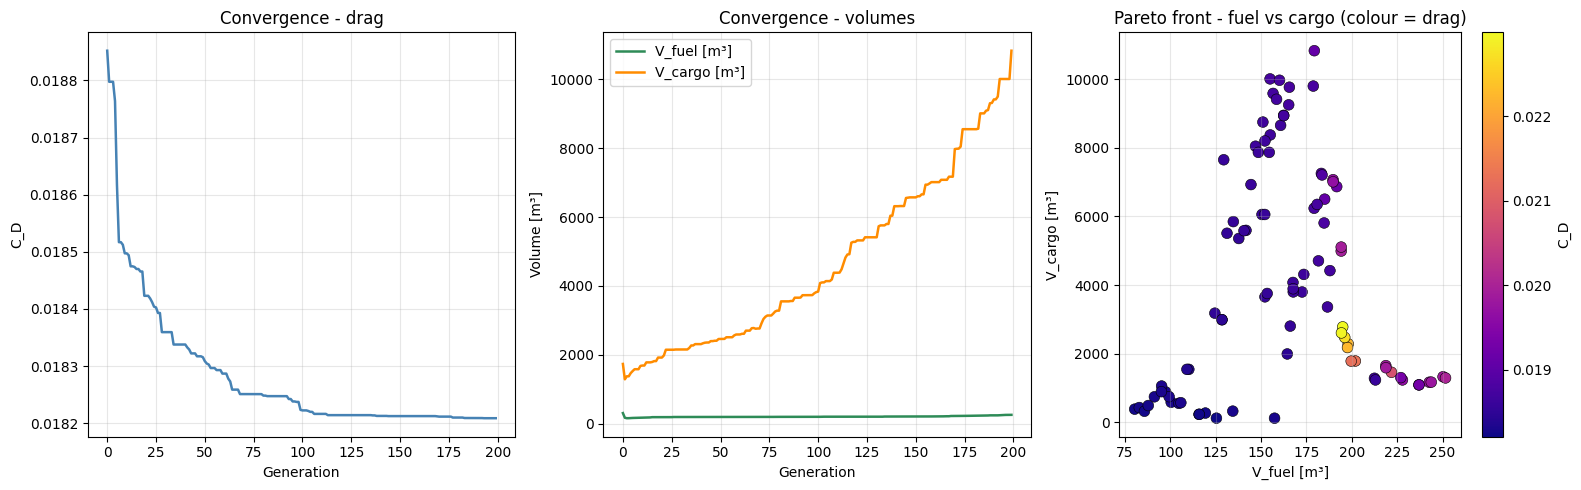

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# convergence – drag
axes[0].plot(history["cd"], color="steelblue", lw=1.8)
axes[0].set_xlabel("Generation"); axes[0].set_ylabel("C_D")
axes[0].set_title("Convergence - drag"); axes[0].grid(alpha=0.3)

# convergence – volumes
axes[1].plot(history["vf"], color="seagreen",  lw=1.8, label="V_fuel [m³]")
axes[1].plot(history["vc"], color="darkorange", lw=1.8, label="V_cargo [m³]")
axes[1].set_xlabel("Generation"); axes[1].set_ylabel("Volume [m³]")
axes[1].set_title("Convergence - volumes"); axes[1].legend(); axes[1].grid(alpha=0.3)

# Pareto front - fuel vs cargo, colour = drag
sc = axes[2].scatter(-pareto_obj[:, 1], -pareto_obj[:, 2],
                     c=pareto_obj[:, 0], cmap="plasma", s=60, edgecolors="k", lw=0.4)
plt.colorbar(sc, ax=axes[2]).set_label("C_D")
axes[2].set_xlabel("V_fuel [m³]"); axes[2].set_ylabel("V_cargo [m³]")
axes[2].set_title("Pareto front - fuel vs cargo (colour = drag)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("aircraft_results.png", dpi=150, bbox_inches="tight")
plt.show()